# Legal Outcome Prediction Pipeline

**Before running:**
1. Launch this notebook on a GPU instance: `ml.g4dn.xlarge` (T4, 16 GB) or `ml.g5.xlarge` (A10G, 24 GB)
2. Upload the `NLPPW` project folder via the JupyterLab file browser **or** git clone it into `/home/sagemaker-user/`
3. Upload `echr-args-dataset.zip` to your S3 bucket
4. Set your HuggingFace token in the cell below

Run all cells in order.

In [1]:
# ── Configure these before running ──────────────────────────────────────────
S3_BUCKET      = ''          # <-- your S3 bucket
S3_DATASET_KEY = ''        # path inside the bucket
HF_TOKEN       = ''       # <-- your HF token
# ────────────────────────────────────────────────────────────────────────────

import os
import sys
from pathlib import Path

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Suppress TensorFlow warnings
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'  # Disable oneDNN custom operations

import warnings
warnings.filterwarnings('ignore')

# Prevent transformers from loading TensorFlow (pre-installed in SageMaker base image)
os.environ['USE_TF'] = '0'

PROJECT_PATH = Path('/home/sagemaker-user/NLPPW')  # adjust if placed elsewhere
os.chdir(PROJECT_PATH)
sys.path.insert(0, str(PROJECT_PATH))

os.environ['HF_TOKEN'] = HF_TOKEN

print('Working directory:', os.getcwd())

Working directory: /home/sagemaker-user/NLPPW


In [2]:
%%capture
!pip install \
    'transformers>=4.40.0' \
    'sentence-transformers>=2.7.0' \
    'datasets>=2.19.0' \
    'huggingface-hub' \
    'scikit-learn>=1.4.0' \
    'interpret>=0.6.0' \
    'numpy>=1.26.0' \
    'pandas>=2.2.0' \
    'matplotlib>=3.8.0' \
    'seaborn>=0.13.0' \
    'tqdm>=4.66.0' \
    'joblib>=1.4.0'
print('Dependencies installed.')

In [3]:
import boto3
import zipfile
import config

ZIP_LOCAL  = PROJECT_PATH / 'echr-args-dataset.zip'
EXTRACT_TO = Path('/home/sagemaker-user/NLPPW')

# Download zip from S3 if not already present
if not ZIP_LOCAL.exists():
    print(f'Downloading s3://{S3_BUCKET}/{S3_DATASET_KEY} ...')
    boto3.client('s3').download_file(S3_BUCKET, S3_DATASET_KEY, str(ZIP_LOCAL))
    print('Download complete.')
else:
    print(f'Zip already present at {ZIP_LOCAL} — skipping download.')

# Extract
if not EXTRACT_TO.exists():
    print(f'Extracting to {EXTRACT_TO} ...')
    with zipfile.ZipFile(ZIP_LOCAL, 'r') as z:
        z.extractall(EXTRACT_TO)
    print('Extraction complete.')
else:
    print(f'Already extracted at {EXTRACT_TO} — skipping.')


config.NEW_DATASET_DIR = EXTRACT_TO / 'all-data'
n_files = len(list(config.NEW_DATASET_DIR.glob('*.json')))
print(f'Dataset ready: {n_files} JSON files')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Zip already present at /home/sagemaker-user/NLPPW/echr-args-dataset.zip — skipping download.
Already extracted at /home/sagemaker-user/NLPPW — skipping.
Dataset ready: 12947 JSON files


In [4]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    print(torch.cuda.get_device_name(0))
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
NVIDIA A10G
VRAM: 23.7 GB


In [5]:
print(f'Dataset dir  : {config.NEW_DATASET_DIR}')
print(f'Stage 1 model: {config.LEGALBERT_MODEL}')
print(f'Stage 2 model: {config.SENTENCE_TRANSFORMER_MODEL}')
print(f'Classifier   : {config.CLASSIFIER_TYPE}')
print(f'Epochs       : {config.S1_EPOCHS}')
print(f'Batch size   : {config.S1_BATCH_SIZE}')
print(f'Fact negatives: {config.FACT_NEGATIVES}  (sim threshold: {config.FACT_SIM_THRESHOLD})')
print(f'Dynamic top-k : {config.DYNAMIC_TOPK}  (alpha: {config.DYNAMIC_TOPK_ALPHA}, floor: {config.PREMISE_FLOOR})')

Dataset dir  : /home/sagemaker-user/NLPPW/all-data
Stage 1 model: /home/sagemaker-user/NLPPW/outputs/stage1_legalbert/checkpoint-best
Stage 2 model: sentence-transformers/all-mpnet-base-v2
Classifier   : svm
Epochs       : 3
Batch size   : 32
Fact negatives: True  (sim threshold: 0.6)
Dynamic top-k : True  (alpha: 0.5, floor: 0.5)


## Stage 1 — Fine-tune LegalBERT (run once)
Fine-tunes LegalBERT on the 12947 case ECtHR dataset.
Splitting is done at the **case_id level** so no case leaks across train/val/test.

**Similarity-filtered fact negatives** (`config.FACT_NEGATIVES`): before fine-tuning, fact sentences
that are dissimilar to any party argument (cosine sim < `FACT_SIM_THRESHOLD`) are added as NON_PREMISE.
Run the inspection cell below to review what gets kept vs filtered.

The checkpoint is saved to `outputs/stage1_legalbert/checkpoint-best`.
**Skip this cell on subsequent runs** — `config.py` auto-detects the saved checkpoint.

In [6]:
from stage1_argument_mining.fact_filter import inspect_fact_negatives

inspect_fact_negatives(n_cases=5, n_sentences=5)


Case: 001-119967  (18 premises, 48 facts)
  KEPT as NON_PREMISE (46):
    sim=0.414  I.  THE CIRCUMSTANCES OF THE CASE
    sim=0.498  The facts of the case, as submitted by the parties, may be summarised as follows.
    sim=0.442  A.  Civil and enforcement proceedings
    sim=0.386  All applicants were former employees of “LETEKS” u stečaju (the debtor), which was, at the relevant time, a company predominantly comprised of socially-owned capital.
    sim=0.404  On 18 April 2008 the Municipal Court in Leskovac ordered the debtor to pay them:
  FILTERED OUT (2):
    sim=0.627  Since the debtor failed to fulfil its contractual obligations towards employees, on unspecified date, the applicants instituted civil proceedings against it.
    sim=0.627  Since the debtor failed to fulfil its contractual obligations towards employees, on unspecified date, the applicants instituted civil proceedings against it.

Case: 001-66687  (36 premises, 108 facts)
  KEPT as NON_PREMISE (46):
    sim=0.486  

In [6]:
import importlib
from pathlib import Path

checkpoint = config.OUTPUT_DIR / 'stage1_legalbert' / 'checkpoint-best'

if checkpoint.exists():
    print(f'Fine-tuned checkpoint found at:\n  {checkpoint}')
    print('Skipping fine-tuning — delete that folder to retrain.')
else:
    print('No checkpoint found. Starting fine-tuning...')
    from stage1_argument_mining.finetune_legalbert import finetune
    finetune()
    importlib.reload(config)
    print(f'\nLEGALBERT_MODEL is now: {config.LEGALBERT_MODEL}')

Fine-tuned checkpoint found at:
  /home/sagemaker-user/NLPPW/outputs/stage1_legalbert/checkpoint-best
Skipping fine-tuning — delete that folder to retrain.


In [7]:
# Evaluate the Stage 1 checkpoint on test set
import numpy as np
from sklearn.metrics import classification_report, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from stage1_argument_mining.finetune_legalbert import prepare_data, ID2LABEL, LABEL2ID

checkpoint = config.OUTPUT_DIR / 'stage1_legalbert' / 'checkpoint-best'

if checkpoint.exists():
    print(f'Evaluating checkpoint: {checkpoint}')
    
    # Load test data
    _, _, test_rows = prepare_data()
    
    # Tokenize
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    test_ds = Dataset.from_dict({
        "text": [r["text"] for r in test_rows],
        "label": [r["label"] for r in test_rows],
    })
    
    def tokenize_batch(batch):
        return tokenizer(batch["text"], truncation=True, max_length=config.S1_MAX_SEQ_LEN, padding="max_length")
    
    test_ds = test_ds.map(tokenize_batch, batched=True, desc="Tokenizing test set")
    
    # Load model
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID)
    
    # Evaluate
    trainer = Trainer(
        model=model,
        args=TrainingArguments(output_dir=str(config.OUTPUT_DIR / "temp"), per_device_eval_batch_size=config.S1_BATCH_SIZE, seed=config.RANDOM_SEED)
    )
    
    out = trainer.predict(test_ds)
    preds = np.argmax(out.predictions, axis=-1)
    
    print("\n" + "="*60)
    print("Stage 1 LegalBERT - Test Set Results")
    print("="*60)
    print(classification_report(out.label_ids, preds, target_names=["NON_PREMISE", "PREMISE"]))
    
    f1_macro = f1_score(out.label_ids, preds, average="macro", zero_division=0)
    f1_binary = f1_score(out.label_ids, preds, average="binary", zero_division=0)
    print(f"\nMacro F1:  {f1_macro:.4f}")
    print(f"Binary F1: {f1_binary:.4f}")
    print("="*60)
else:
    print("No checkpoint found. Run fine-tuning first.")

Evaluating checkpoint: /home/sagemaker-user/NLPPW/outputs/stage1_legalbert/checkpoint-best
Loading new dataset from /home/sagemaker-user/NLPPW/all-data ...
  8364 unique case_ids loaded (argument units)
  Loading cached fact negatives from /home/sagemaker-user/NLPPW/outputs/fact_negatives_filtered.json
  + 457905 similarity-filtered fact negatives from 8315 cases
  Case-level split: 5856 train / 1254 val / 1254 test cases

Split sizes (train after balancing):
  train :  412540 sentences  (206270 premises / 206270 non-premises)
  val   :  121109 sentences  (44805 premises / 76304 non-premises)
  test  :  122092 sentences  (44595 premises / 77497 non-premises)


Tokenizing test set:   0%|          | 0/122092 [00:00<?, ? examples/s]

E0000 00:00:1778843982.064960     443 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778843982.075935     443 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778843982.249499     443 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778843982.249519     443 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778843982.249522     443 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778843982.249524     443 computation_placer.cc:177] computation placer already registered. Please check linka


Stage 1 LegalBERT - Test Set Results
              precision    recall  f1-score   support

 NON_PREMISE       0.99      0.95      0.97     77497
     PREMISE       0.93      0.98      0.95     44595

    accuracy                           0.96    122092
   macro avg       0.96      0.97      0.96    122092
weighted avg       0.96      0.96      0.96    122092


Macro F1:  0.9603
Binary F1: 0.9504


## Stage 1 — Argument Mining
Loads the fine-tuned LegalBERT and classifies each sentence as a premise or not.

In [9]:
from pathlib import Path
from data.data_loader import get_dataset
from stage1_argument_mining.sequence_filter import run_stage1, load_stage1, print_stage1_stats

dataset = get_dataset()

if Path(config.STAGE1_CACHE).exists():
    print(f'Cached premises found at {config.STAGE1_CACHE} — skipping extraction.')
    print('Delete this file to re-run Stage 1 extraction.')
    stage1_output = load_stage1()
else:
    from stage1_argument_mining.argument_extractor import LegalBERTArgumentExtractor
    extractor = LegalBERTArgumentExtractor()
    stage1_output = run_stage1(dataset, extractor)

print_stage1_stats(stage1_output)

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'lex_glue' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Cached premises found at /home/sagemaker-user/NLPPW/outputs/stage1_extracted_premises.json — skipping extraction.
Delete this file to re-run Stage 1 extraction.

Stage 1 – Argument Mining Statistics
  [train] cases= 9000  total_premises=102067  avg= 11.3  zero_premise_cases=811
  [  val] cases= 1000  total_premises= 13664  avg= 13.7  zero_premise_cases=49
  [ test] cases= 1000  total_premises= 14284  avg= 14.3  zero_premise_cases=39


In [8]:
from stage1_argument_mining.argument_extractor import _split_sentences, LegalBERTArgumentExtractor

print('Stage 1 model:', config.LEGALBERT_MODEL)
print(f'Dynamic top-k: {config.DYNAMIC_TOPK}  (alpha={config.DYNAMIC_TOPK_ALPHA}, floor={config.PREMISE_FLOOR})')
print()

# Build extractor only for diagnostics if not already loaded
if 'extractor' not in dir() or extractor is None:
    extractor = LegalBERTArgumentExtractor()

sample_paragraphs = dataset['test'][9]['paragraphs']
print(f'Probing first test case ({len(sample_paragraphs)} paragraphs), raw scores:\n')
for para in sample_paragraphs[:]:
    for sent in _split_sentences(para):
        is_p, conf = extractor.predict_sentence(sent)
        label = 'PREMISE' if is_p else '---'
        print(f'  {conf:.3f}  {label:<10}  {sent[:]}')

premises = extractor.extract_premises(sample_paragraphs)
print(f'\nDynamic top-k selected {len(premises)} premises:')
for p in premises:
    print(f'  {p["confidence"]:.3f}  [para {p["paragraph_id"]}]  {p["sentence"][:120]}')

Stage 1 model: /home/sagemaker-user/NLPPW/outputs/stage1_legalbert/checkpoint-best
Dynamic top-k: True  (alpha=0.5, floor=0.5)

Probing first test case (12 paragraphs), raw scores:

  0.416  ---         The applicant, S.S.
  0.000  ---         Yeniköy Konut Yapı Kooperatifi, is a housing construction cooperative under Turkish law operating in İzmir.
  0.006  ---         In 1993, a third party cooperative bought a plot of land measuring 12,000 square metres and the title deed of the land was registered in its name.
  0.007  ---         In 1995, construction works started on the land in question.
  0.001  ---         In 2000, the forest administration initiated proceedings before the Menderes Civil Court of First Instance for the annulment of the title deed to the land, alleging that it was part of the public forest area.
  0.967  PREMISE     In the meantime, the third party cooperative had merged with the applicant cooperative and the land had been registered in the Land Registry in the

## Stage 2 — Outcome Prediction
Embeds extracted premises with Sentence-BERT and trains the classifier.

In [8]:
from pathlib import Path
from stage2_outcome_prediction.embedder import PremiseEmbedder
from stage2_outcome_prediction.classifier import (
    train_classifier, save_classifier, load_classifier, quick_eval)

embedder = PremiseEmbedder()

X_train, y_train = embedder.prepare_split(stage1_output['train'])
X_val,   y_val   = embedder.prepare_split(stage1_output['val'])
X_test,  y_test  = embedder.prepare_split(stage1_output['test'])

if Path(config.MODEL_CACHE).exists():
    print(f'Cached classifier found at {config.MODEL_CACHE} — skipping training.')
    print('Delete this file to retrain.')
    clf = load_classifier()
else:
    clf = train_classifier(X_train, y_train)
    save_classifier(clf)

quick_eval(clf, X_val, y_val)

Batches:   0%|          | 0/1595 [00:00<?, ?it/s]

Batches:   0%|          | 0/214 [00:00<?, ?it/s]

Batches:   0%|          | 0/224 [00:00<?, ?it/s]

Cached classifier found at /home/sagemaker-user/NLPPW/outputs/stage2_classifier.joblib — skipping training.
Delete this file to retrain.
Val  Macro-F1=0.5963  Micro-F1=0.6357


{'macro_f1': 0.5963407431757558, 'micro_f1': 0.6357142857142857}

In [9]:
# Enable hybrid mode
import config
config.USE_HYBRID_EMBEDDER = True
print(f"Hybrid mode: {config.USE_HYBRID_EMBEDDER}")
print(f"Premise weight boost: {config.HYBRID_PREMISE_WEIGHT_BOOST}")

Hybrid mode: True
Premise weight boost: 2.0


In [10]:
from pathlib import Path
from stage2_outcome_prediction.embedder_hybrid import HybridPremiseEmbedder
from stage2_outcome_prediction.classifier import (
    train_classifier, save_classifier, load_classifier, quick_eval)

embedder_hybrid = HybridPremiseEmbedder()
print("Using HYBRID embedder (full paragraphs + premise features)")

X_train_hybrid, y_train_hybrid = embedder_hybrid.prepare_split(stage1_output['train'])
X_val_hybrid,   y_val_hybrid   = embedder_hybrid.prepare_split(stage1_output['val'])
X_test_hybrid,  y_test_hybrid  = embedder_hybrid.prepare_split(stage1_output['test'])

print(f"\nFeature dimensions:")
print(f"  Premise-only: {X_train.shape[1]} features")
print(f"  Hybrid:       {X_train_hybrid.shape[1]} features")

# Save hybrid classifier with different cache name
HYBRID_MODEL_CACHE = config.OUTPUT_DIR / "stage2_classifier_hybrid.joblib"

if Path(HYBRID_MODEL_CACHE).exists():
    print(f'Cached hybrid classifier found at {HYBRID_MODEL_CACHE} — skipping training.')
    print('Delete this file to retrain.')
    clf_hybrid = load_classifier(HYBRID_MODEL_CACHE)
else:
    clf_hybrid = train_classifier(X_train_hybrid, y_train_hybrid)
    save_classifier(clf_hybrid, HYBRID_MODEL_CACHE)

quick_eval(clf_hybrid, X_val_hybrid, y_val_hybrid)

Using HYBRID embedder (full paragraphs + premise features)
[Hybrid] Embedding 212878 paragraphs from 9000 cases...


Batches:   0%|          | 0/3327 [00:00<?, ?it/s]

[Hybrid] Embedding 24418 paragraphs from 1000 cases...


Batches:   0%|          | 0/382 [00:00<?, ?it/s]

[Hybrid] Embedding 25284 paragraphs from 1000 cases...


Batches:   0%|          | 0/396 [00:00<?, ?it/s]


Feature dimensions:
  Premise-only: 2309 features
  Hybrid:       2313 features
Cached hybrid classifier found at /home/sagemaker-user/NLPPW/outputs/stage2_classifier_hybrid.joblib — skipping training.
Delete this file to retrain.
Val  Macro-F1=0.6235  Micro-F1=0.6886


{'macro_f1': 0.623491631677364, 'micro_f1': 0.6885911490052781}

## Evaluation

In [12]:
from stage2_outcome_prediction.classifier import predict, predict_with_thresholds, tune_thresholds
from evaluation.metrics import (compare_classifiers, per_article_f1,
                                 print_per_article_f1, train_baseline_classifier)
from evaluation.qualitative_review import run_qualitative_review
from data.data_loader import ARTICLE_NAMES

print("="*70)
print("THREE-WAY EVALUATION: Baseline vs Premise vs Hybrid")
print("="*70)

# 1. Baseline (raw text, no premise extraction)
print("\n[1/3] Training baseline (raw text)...")
y_pred_baseline, clf_baseline = train_baseline_classifier(
    stage1_output['train'], stage1_output['test'], embedder)

# 2. Premise (current approach)
print("\n[2/3] Evaluating premise classifier...")
thresholds_premise = tune_thresholds(clf, X_val, y_val)
print("  Tuned thresholds:")
for name, t in zip(ARTICLE_NAMES, thresholds_premise):
    print(f"    {name:<12} threshold={t:+.4f}")
y_pred_premise = predict_with_thresholds(clf, X_test, thresholds_premise)

# 3. Hybrid (full-text with premise features)
print("\n[3/3] Evaluating hybrid classifier...")
thresholds_hybrid = tune_thresholds(clf_hybrid, X_val_hybrid, y_val_hybrid)
y_pred_hybrid = predict_with_thresholds(clf_hybrid, X_test_hybrid, thresholds_hybrid)

# Overall metrics comparison
print("\n" + "="*70)
print("OVERALL METRICS")
print("="*70)
print(f"{'Metric':<22} {'Baseline':>15} {'Premise':>15} {'Hybrid':>15}")
print("="*70)

from evaluation.metrics import compute_metrics
metrics_baseline = compute_metrics(y_test, y_pred_baseline)
metrics_premise = compute_metrics(y_test, y_pred_premise)
metrics_hybrid = compute_metrics(y_test_hybrid, y_pred_hybrid)

for metric in ['macro_f1', 'micro_f1', 'macro_precision', 'macro_recall', 'micro_precision', 'micro_recall']:
    b = metrics_baseline[metric]
    p = metrics_premise[metric]
    h = metrics_hybrid[metric]
    print(f"{metric:<22} {b:>15.4f} {p:>15.4f} {h:>15.4f}")
print("="*70)

# Per-article comparison
pa_f1_baseline = per_article_f1(y_test, y_pred_baseline)
pa_f1_premise = per_article_f1(y_test, y_pred_premise)
pa_f1_hybrid = per_article_f1(y_test_hybrid, y_pred_hybrid)

baseline_dict = {r['article']: r['f1'] for r in pa_f1_baseline}
premise_dict = {r['article']: r['f1'] for r in pa_f1_premise}
hybrid_dict = {r['article']: r['f1'] for r in pa_f1_hybrid}

print("\n" + "="*80)
print("PER-ARTICLE F1 SCORES")
print("="*80)
print(f"{'Article':<16} {'Baseline':>15} {'Premise':>15} {'Hybrid':>15} {'Support':>10}")
print("="*80)

for r in pa_f1_baseline:
    article = r['article']
    b = baseline_dict.get(article, 0.0)
    p = premise_dict.get(article, 0.0)
    h = hybrid_dict.get(article, 0.0)
    support = r['support']
    print(f"{article:<16} {b:>15.4f} {p:>15.4f} {h:>15.4f} {support:>10}")
print("="*80)

# Determine best approach
best = max([('Baseline', metrics_baseline['macro_f1']),
            ('Premise', metrics_premise['macro_f1']),
            ('Hybrid', metrics_hybrid['macro_f1'])], key=lambda x: x[1])
print(f"\nBest approach: {best[0]} (macro F1: {best[1]:.4f})")

THREE-WAY EVALUATION: Baseline vs Premise vs Hybrid

[1/3] Training baseline (raw text)...


Batches:   0%|          | 0/141 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]


[2/3] Evaluating premise classifier...
  Tuned thresholds:
    Article 2    threshold=+0.1550
    Article 3    threshold=+0.2552
    Article 5    threshold=+0.0615
    Article 6    threshold=+0.0109
    Article 8    threshold=+0.7555
    Article 9    threshold=-0.0425
    Article 10   threshold=+0.3337
    Article 11   threshold=+0.0176
    Article 14   threshold=+0.0423
    P1-1         threshold=+0.3087

[3/3] Evaluating hybrid classifier...

OVERALL METRICS
Metric                        Baseline         Premise          Hybrid
macro_f1                        0.4887          0.4949          0.5639
micro_f1                        0.5440          0.5583          0.6528
macro_precision                 0.4138          0.4822          0.5364
macro_recall                    0.6945          0.5336          0.6128
micro_precision                 0.4593          0.5381          0.6364
micro_recall                    0.6669          0.5800          0.6702

PER-ARTICLE F1 SCORES
Article       


PREMISE COUNT ANALYSIS - Classical ML (SVM/DT/EBM)

Performance by number of extracted premises:
Premises   N Cases    Baseline (macro)   Baseline (micro)   Premise (macro)    Premise (micro)    Hybrid (macro)     Hybrid (micro)    
0          39                     0.3255             0.6139             0.2320             0.5773             0.2181             0.5682
1          57                     0.3606             0.6951             0.2507             0.6174             0.2970             0.7015
2          52                     0.4994             0.6957             0.3418             0.5645             0.3889             0.6667
3-5        165                    0.4795             0.6119             0.4487             0.5694             0.5139             0.7107
6-10       198                    0.4681             0.5543             0.4700             0.5032             0.4762             0.6101
10+        489                    0.4578             0.4839             0.5124        

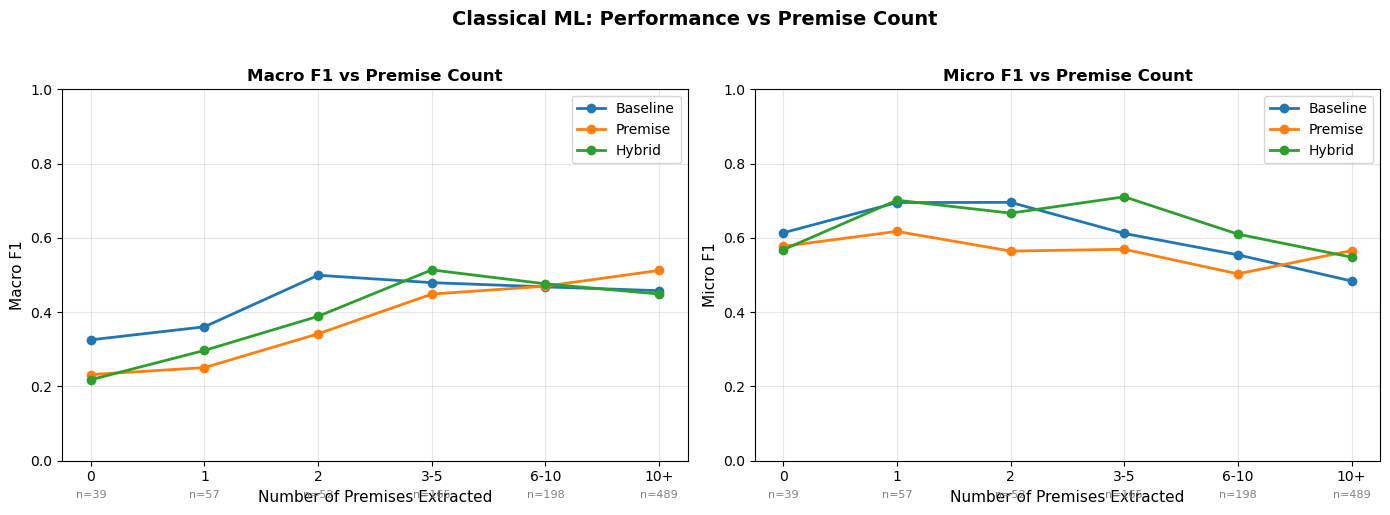

In [14]:
import importlib
import evaluation.premise_count_analysis
importlib.reload(evaluation.premise_count_analysis)

#Premise Count Analysis - Classical ML
from evaluation.premise_count_analysis import (
    group_cases_by_premise_count, plot_premise_count_analysis, print_premise_count_table)

print("\n" + "="*70)
print("PREMISE COUNT ANALYSIS - Classical ML (SVM/DT/EBM)")
print("="*70)

predictions_classical = {
    'Baseline': y_pred_baseline,
    'Premise': y_pred_premise,
    'Hybrid': y_pred_hybrid
}

results_classical = group_cases_by_premise_count(stage1_output['test'], predictions_classical)

print("\nPerformance by number of extracted premises:")
print_premise_count_table(results_classical)

plot_premise_count_analysis(
    results_classical,
    title="Classical ML: Performance vs Premise Count",
    output_path=config.OUTPUT_DIR / "premise_count_analysis_classical.png",
    colors={'Baseline': '#1f77b4', 'Premise': '#ff7f0e', 'Hybrid': '#2ca02c'}
)

## LegalBERT Classifier Comparison
Validates that Stage 1 premise extraction adds value: fine-tunes LegalBERT as a multi-label classifier on **extracted premises only** vs **full text**, then compares both against the explainable pipeline.

This is an additional experiment — our main pipeline remains the explainable SVM/DT/EBM approach.

In [12]:
from stage2_outcome_prediction.bert_classifier import train_bert_classifier, predict_bert
from evaluation.metrics import compute_metrics, per_article_f1, EVAL_ARTICLE_NAMES

hp_config = {'epochs': 8, 'batch_size': 16, 'lr': 3e-5, 'wr': 0.1, 'wd': 0.06} 

print("\n" + "="*70)
print("STEP 2: TRAINING ALL 3 BERT APPROACHES WITH TUNED CONFIG")
print("="*70)

bert_results = {}
y_test_bert = np.array([c['labels_binary'] for c in stage1_output['test']])

# Full-text (already trained, just evaluate)
print('\n[1/3] Training LegalBERT on full text...')
model_full, tok_full = train_bert_classifier(
    stage1_output['train'], stage1_output['val'],
    use_premises=False, use_hybrid=False, 
    epochs=hp_config['epochs'], 
    batch_size=hp_config['batch_size'],
    lr=hp_config['lr'],
    warmup_ratio=hp_config['wr'],
    weight_decay=hp_config['wd'])
y_pred_full = predict_bert(model_full, tok_full, stage1_output['test'], 
                           use_premises=False, use_hybrid=False)
bert_results['fulltext_bert'] = compute_metrics(y_test_bert, y_pred_full)
bert_results['fulltext_bert']['per_article'] = per_article_f1(y_test_bert, y_pred_full)
print(f'  Full-text LegalBERT  macro_f1={bert_results["fulltext_bert"]["macro_f1"]:.4f}  '
      f'micro_f1={bert_results["fulltext_bert"]["micro_f1"]:.4f}')

# Premises-only (train with same config)
print(f'\n[2/3] Premises BERT (epochs={hp_config["epochs"]}, '
    f'batch_size={hp_config["batch_size"]}, lr={hp_config["lr"]:.0e})')
model_prem, tok_prem = train_bert_classifier(
  stage1_output['train'], stage1_output['val'],
  use_premises=True, use_hybrid=False,
  epochs=hp_config['epochs'], 
  batch_size=hp_config['batch_size'],
  lr=hp_config['lr'],
  warmup_ratio=hp_config['wr'],
  weight_decay=hp_config['wd']
)
y_pred_prem = predict_bert(model_prem, tok_prem, stage1_output['test'],
                        use_premises=True, use_hybrid=False)
bert_results['premises_bert'] = compute_metrics(y_test_bert, y_pred_prem)
bert_results['premises_bert']['per_article'] = per_article_f1(y_test_bert, y_pred_prem)
print(f'  macro_f1={bert_results["premises_bert"]["macro_f1"]:.4f}, '
    f'micro_f1={bert_results["premises_bert"]["micro_f1"]:.4f}')

# Hybrid (train with same config)
print(f'\n[3/3] Hybrid BERT (epochs={hp_config["epochs"]}, '
    f'batch_size={hp_config["batch_size"]}, lr={hp_config["lr"]:.0e})')
model_hybrid, tok_hybrid = train_bert_classifier(
  stage1_output['train'], stage1_output['val'],
  use_premises=False, use_hybrid=True,
  epochs=hp_config['epochs'], 
  batch_size=hp_config['batch_size'],
  lr=hp_config['lr'],
  warmup_ratio=hp_config['wr'],
  weight_decay=hp_config['wd']
)
y_pred_hybrid = predict_bert(model_hybrid, tok_hybrid, stage1_output['test'],
                          use_premises=False, use_hybrid=True)
bert_results['hybrid_bert'] = compute_metrics(y_test_bert, y_pred_hybrid)
bert_results['hybrid_bert']['per_article'] = per_article_f1(y_test_bert, y_pred_hybrid)
print(f'  macro_f1={bert_results["hybrid_bert"]["macro_f1"]:.4f}, '
    f'micro_f1={bert_results["hybrid_bert"]["micro_f1"]:.4f}')


STEP 2: TRAINING ALL 3 BERT APPROACHES WITH TUNED CONFIG

[1/3] Training LegalBERT on full text...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nlpaueb/bert-base-uncased-echr and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using warmup: 450/4504 steps (ratio=0.1)


Epoch 1/8: 100%|██████████| 563/563 [04:20<00:00,  2.16it/s]


  loss=0.3035  val_macro_f1=0.3539  val_micro_f1=0.6032


...

  loss=0.0541  val_macro_f1=0.6363  val_micro_f1=0.6961


Epoch 7/8: 100%|██████████| 563/563 [04:23<00:00,  2.14it/s]


  loss=0.0399  val_macro_f1=0.6353  val_micro_f1=0.6932


Epoch 8/8: 100%|██████████| 563/563 [04:23<00:00,  2.14it/s]


  loss=0.0318  val_macro_f1=0.6381  val_micro_f1=0.6991
  macro_f1=0.5685, micro_f1=0.6329


In [13]:
# --- Three-way comparison table ---
print(f'\n{"="*70}')
print("OVERALL METRICS")
print(f'{"="*70}')
print(f'{"Metric":<22} {"Full-text":>15} {"Premises":>15} {"Hybrid":>15}')
print(f'{"="*70}')
for m in ['macro_f1', 'micro_f1', 'macro_precision', 'macro_recall', 'hamming_loss']:
    f = bert_results['fulltext_bert'][m]
    p = bert_results['premises_bert'][m]
    h = bert_results['hybrid_bert'][m]
    print(f'{m:<22} {f:>15.4f} {p:>15.4f} {h:>15.4f}')
print(f'{"="*70}')

print(f'\n{"="*70}')
print("PER-ARTICLE F1 SCORES")
print(f'{"="*70}')
print(f'{"Article":<16} {"Full-text":>15} {"Premises":>15} {"Hybrid":>15}')
print(f'{"="*70}')
for name in EVAL_ARTICLE_NAMES:
    pa_f = {r['article']: r['f1'] for r in bert_results['fulltext_bert'].get('per_article', [])}
    pa_p = {r['article']: r['f1'] for r in bert_results['premises_bert'].get('per_article', [])}
    pa_h = {r['article']: r['f1'] for r in bert_results['hybrid_bert'].get('per_article', [])}
    print(f'{name:<16} {pa_f.get(name, 0.0):>15.4f} {pa_p.get(name, 0.0):>15.4f} {pa_h.get(name, 0.0):>15.4f}')
print(f'{"="*70}')

# Determine best approach
best = max([('Full-text', bert_results['fulltext_bert']['macro_f1']),
            ('Premises', bert_results['premises_bert']['macro_f1']),
            ('Hybrid', bert_results['hybrid_bert']['macro_f1'])], key=lambda x: x[1])
print(f'\nBest LegalBERT approach: {best[0]} (macro F1: {best[1]:.4f})')


OVERALL METRICS
Metric                       Full-text        Premises          Hybrid
macro_f1                        0.5557          0.5728          0.5685
micro_f1                        0.6355          0.6524          0.6329
macro_precision                 0.6607          0.6474          0.6313
macro_recall                    0.5418          0.5394          0.5325
hamming_loss                    0.0815          0.0767          0.0804

PER-ARTICLE F1 SCORES
Article                Full-text        Premises          Hybrid
Article 2                 0.8455          0.7890          0.8364
Article 3                 0.6986          0.7969          0.7236
Article 5                 0.6775          0.7333          0.7226
Article 6                 0.6818          0.6917          0.6831
Article 8                 0.6068          0.5702          0.5505
Article 9                 0.2500          0.2857          0.2500
Article 10                0.4677          0.4839          0.4426
Article 11    


PREMISE COUNT ANALYSIS - LegalBERT (Deep Learning)

Performance by number of extracted premises:
Premises   N Cases    Full-text (macro)  Full-text (micro)  Premises (macro)   Premises (micro)   Hybrid (macro)     Hybrid (micro)    
0          39                     0.4148             0.7500             0.3312             0.6429             0.4109             0.7191
1          57                     0.3996             0.6715             0.1746             0.5970             0.4469             0.7500
2          52                     0.4247             0.6822             0.2148             0.5469             0.3988             0.7273
3-5        165                    0.6004             0.7549             0.5229             0.6898             0.5602             0.7200
6-10       198                    0.4864             0.5839             0.5966             0.6446             0.5547             0.5996
10+        489                    0.5474             0.5982             0.6058        

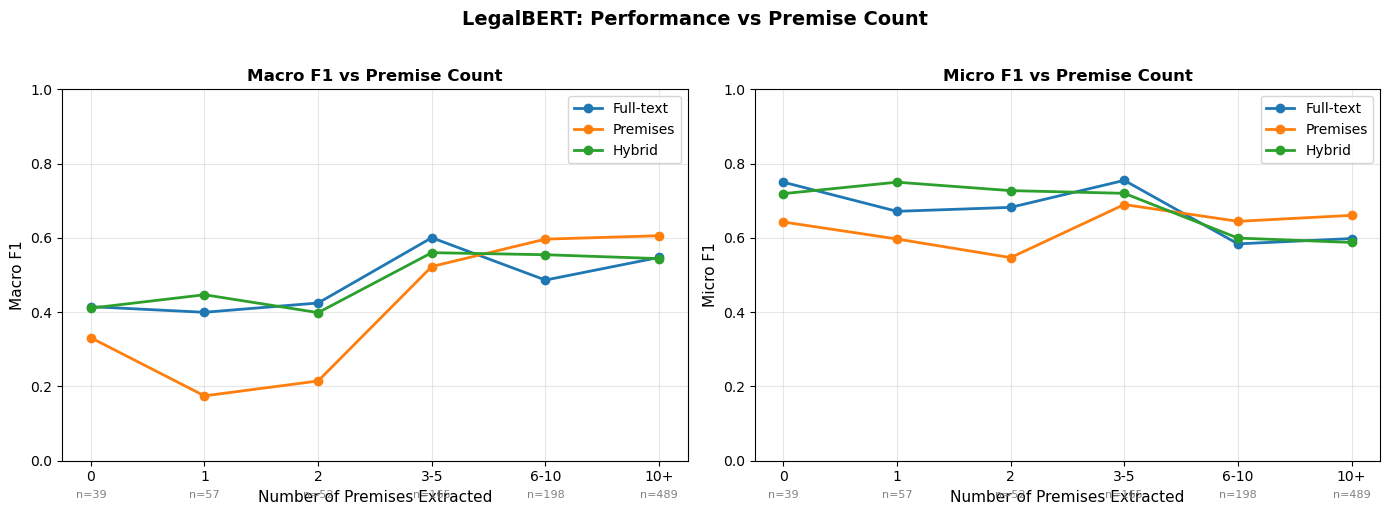

In [20]:
from evaluation.premise_count_analysis import (
    group_cases_by_premise_count, plot_premise_count_analysis, print_premise_count_table)

print("\n" + "="*70)
print("PREMISE COUNT ANALYSIS - LegalBERT (Deep Learning)")
print("="*70)

predictions_bert = {
    'Full-text': y_pred_full,
    'Premises': y_pred_prem,
    'Hybrid': y_pred_hybrid
}

results_bert = group_cases_by_premise_count(stage1_output['test'], predictions_bert)

print("\nPerformance by number of extracted premises:")
print_premise_count_table(results_bert)

plot_premise_count_analysis(
    results_bert,
    title="LegalBERT: Performance vs Premise Count",
    output_path=config.OUTPUT_DIR / "premise_count_analysis_bert.png",
    colors={'Full-text': '#1f77b4', 'Premises': '#ff7f0e', 'Hybrid': '#2ca02c'}
)

## Save Outputs to S3
Uploads the fine-tuned checkpoint and all output artifacts back to S3 for safekeeping.

In [21]:
import boto3
from pathlib import Path

s3     = boto3.client('s3')
OUTPUT = config.OUTPUT_DIR

def upload_dir_to_s3(local_dir: Path, s3_prefix: str):
    files = [f for f in local_dir.rglob('*') if f.is_file()]
    for f in files:
        key = f'{s3_prefix}/{f.relative_to(local_dir)}'
        s3.upload_file(str(f), S3_BUCKET, key)
    print(f'Uploaded {len(files)} files → s3://{S3_BUCKET}/{s3_prefix}/')

upload_dir_to_s3(OUTPUT, 'nlppw/outputs')
print('Done.')

Uploaded 23 files → s3://nlppw-echr-args-dara-712151682132-us-east-1-an/nlppw/outputs/
Done.
